# Does Outside Money Win Elections?

*Super PAC spending and electoral outcomes in 2024 U.S. House races*

---

In 2024, Super PAC money flowed overwhelmingly toward close races and candidates who were already strong, not toward long shots. Candidates with Super PAC backing won **55%** of competitive races versus **41%** without it. But once incumbency and party are taken into account, outside money becomes a *secondary* predictor of victory, behind both. The clearest reading of the data: **Super PAC spending marks winners more than it makes them.**

## Background

Since the Supreme Court's *Citizens United* decision in 2010, Super PACs, independent expenditure-only committees that can raise and spend unlimited sums, have reshaped American elections. Outside spending on federal races reached a record **$4.5 billion** in 2024. Critics argue this gives wealthy donors outsized influence over who wins; defenders counter that the money simply chases candidates who are already viable. This report tests that question against the data.

The analysis is organized around four questions:

1. **Does Super PAC spending track electoral outcomes** — vote share and win/loss?
2. **Is it more important than a candidate's own fundraising?**
3. **Where does the money flow** — competitive or safe districts?
4. **Do Democrats and Republicans deploy it differently?**

**A note on causation.** Every relationship reported here is *associative, not causal*. Super PACs deliberately back candidates who are already competitive, so outside money and a candidate's underlying strength are entangled by design — no observational analysis can fully separate the two. Rather than overstate what the data can show, this report treats that limitation as part of the finding.

## The data

The analysis combines three public datasets covering the 2024 U.S. House:

- **MIT Election Lab — U.S. House returns (1976–2024).** Certified, district-level general-election results from the Harvard Dataverse. We use the 2024 general election to compute each district's two-party vote share, margin of victory, and winner.
- **FEC Independent Expenditures (2023–24 cycle).** Transaction-level records of money spent *for* (type 24E) and *against* (type 24A) federal candidates by outside groups. We keep only committees registered as Independent Expenditure-Only (committee type "O") — i.e. Super PACs — and aggregate their spending to the candidate level.
- **FEC Candidate Summary (2024).** Each candidate's total disbursements (their own campaign spending) and incumbency status, used both as a control and to answer the fundraising question.

### How competitiveness and spending are defined

**District competitiveness** is classified by the two-party margin of victory: **Toss-up** (0–5 points), **Competitive** (5–15), **Likely Safe** (15–30), and **Safe** (30+). This lets us ask not just *how much* outside money flows, but *where*, and whether it concentrates where races are genuinely in play.

**Super PAC spending** is the sum of independent expenditures by type-"O" committees on a given candidate, split into money spent *for* the candidate and money spent *against* them. Both directions matter: a candidate can be boosted by allies and attacked by opponents, and the two carry very different strategic logic.

## Building the analysis dataset

From the raw files we keep only 2024 general-election results, compute each district's vote share and margin, and classify competitiveness. On the finance side, we isolate independent expenditures (24E/24A) made by Super PACs and aggregate them per candidate into spending *for* and *against*. We then merge in each candidate's own disbursements and incumbency status. The result is one row per major-party candidate combining electoral outcome, outside spending, and self-funding, the single table behind every query and chart below. It is also written to a SQLite database so the relationships can be explored with SQL.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt

# Election results (MIT) 
house = pd.read_csv("1976-2024-house.tab", sep=",", low_memory=False)

# PAC spending (FEC)
pac_headers = pd.read_csv("pas2_header_file.csv")
col_names = pac_headers.columns.tolist()

pac = pd.read_csv("itpas2.txt", sep="|", header=None,
                  names=col_names, low_memory=False)

# Committee master (FEC) 
cm_headers = pd.read_csv("cm_header_file.csv")
cm_col_names = cm_headers.columns.tolist()

cm = pd.read_csv("cm.txt", sep="|", header=None,
                 names=cm_col_names, low_memory=False)

# Candidate summary (FEC)
cand_cols = [
    "CAND_ID", "CAND_NAME", "CAND_ICI", "PTY_CD", "CAND_PTY_AFFILIATION",
    "TTL_RECEIPTS", "TRANS_FROM_AUTH", "TTL_DISB", "TRANS_TO_AUTH",
    "COH_BOP", "COH_COP", "CAND_CONTRIB", "CAND_LOANS", "OTHER_LOANS",
    "CAND_LOAN_REPAY", "OTHER_LOAN_REPAY", "DEBTS_OWED_BY",
    "TTL_INDIV_CONTRIB", "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT",
    "SPEC_ELECTION", "PRIM_ELECTION", "RUN_ELECTION", "GEN_ELECTION",
    "GEN_ELECTION_PRECENT", "OTHER_POL_CMTE_CONTRIB",
    "POL_PTY_CONTRIB", "CVG_END_DT", "INDIV_REFUNDS", "CMTE_REFUNDS"
]

cand = pd.read_csv("weball24.txt", sep="|", header=None,
                   names=cand_cols, low_memory=False)



In [2]:
# Plot style
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.titlepad": 12, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})
DEM, REP = "#2171b5", "#cb181d"
ACCENT, NEUTRAL = "#6a0dad", "#9e9e9e"
COMP_COLORS = {"Toss-up": "#6a0dad", "Competitive": "#9b59b6",
               "Likely Safe": "#c9b3e0", "Safe": "#d9d9d9"}

In [3]:
# Keeping only 2024 general elections
house_2024 = house[
    (house["year"] == 2024) &
    (house["stage"] == "GEN") &
    (house["special"] == False) &
    (house["writein"] == False)
].copy()



In [4]:
# Calculating vote share for each candidate
house_2024["vote_share"] = house_2024["candidatevotes"] / house_2024["totalvotes"] * 100

# Keeping only Democrat and Republican candidates
house_2024_major = house_2024[
    house_2024["party"].isin(["DEMOCRAT", "REPUBLICAN"])
].copy()

In [5]:
# For each district, finding the top two vote shares and calculate margin
district_results = house_2024_major.groupby(
    ["state_po", "district", "party"]
)["vote_share"].sum().reset_index()

# Pivoting so Democrat and Republican are columns
district_pivot = district_results.pivot_table(
    index=["state_po", "district"],
    columns="party",
    values="vote_share"
).reset_index()

district_pivot.columns.name = None
district_pivot = district_pivot.rename(columns={
    "DEMOCRAT": "dem_pct",
    "REPUBLICAN": "rep_pct"
})

In [6]:
# Calculating margin of victory
district_pivot["margin"] = abs(
    district_pivot["dem_pct"] - district_pivot["rep_pct"]
)

In [7]:
# Classifying districts as competitive or safe
def classify_district(margin):
    if margin <= 5:
        return "Toss-up"
    elif margin <= 15:
        return "Competitive"
    elif margin <= 30:
        return "Likely Safe"
    else:
        return "Safe"

district_pivot["competitiveness"] = district_pivot["margin"].apply(classify_district)



In [8]:
# Filling NaN with 0 (no candidate from that party = 0%)
district_pivot["dem_pct"] = district_pivot["dem_pct"].fillna(0)
district_pivot["rep_pct"] = district_pivot["rep_pct"].fillna(0)

# Recalculating margin after filling NaN
district_pivot["margin"] = abs(district_pivot["dem_pct"] - district_pivot["rep_pct"])

# Reclassify after fix
district_pivot["competitiveness"] = district_pivot["margin"].apply(classify_district)

# Also adding winner column
district_pivot["winner_party"] = district_pivot.apply(
    lambda row: "REPUBLICAN" if row["rep_pct"] > row["dem_pct"] else "DEMOCRAT",
    axis=1
)



In [9]:
# Filtering only Super PACs from committee master
# Super PACs have committee type "O" (Independent Expenditure-Only)
super_pacs = cm[cm["CMTE_TP"] == "O"][["CMTE_ID", "CMTE_NM", "CMTE_TP"]].copy()



In [10]:
# Filtering PAC spending for independent expenditures only
# 24E = expenditure FOR a candidate, 24A = expenditure AGAINST a candidate
ie_spending = pac[pac["TRANSACTION_TP"].isin(["24E", "24A"])].copy()

In [11]:
# Keeping only spending from Super PACs
superpac_spending = ie_spending[
    ie_spending["CMTE_ID"].isin(super_pacs["CMTE_ID"])
].copy()



In [12]:
# Aggregating Super PAC spending by candidate
superpac_by_cand = superpac_spending.groupby(
    ["CAND_ID", "TRANSACTION_TP"]
)["TRANSACTION_AMT"].sum().reset_index()

# Pivoting so we have separate columns for spending FOR and AGAINST
superpac_pivot = superpac_by_cand.pivot_table(
    index="CAND_ID",
    columns="TRANSACTION_TP",
    values="TRANSACTION_AMT",
    fill_value=0
).reset_index()

superpac_pivot.columns.name = None
superpac_pivot = superpac_pivot.rename(columns={
    "24E": "superpac_for",
    "24A": "superpac_against"
})

In [13]:
# Calculating total Super PAC spending per candidate
superpac_pivot["superpac_total"] = (
    superpac_pivot["superpac_for"] + superpac_pivot["superpac_against"]
)



In [14]:
# Keeping only House candidates from candidate summary
cand_house = cand[cand["CAND_ID"].str.startswith("H")].copy()

# Merging Super PAC spending with candidate info
cand_superpac = cand_house.merge(
    superpac_pivot,
    on="CAND_ID",
    how="left"
)

In [15]:
# Filling NaN with 0 for candidates with no Super PAC spending
cand_superpac["superpac_for"] = cand_superpac["superpac_for"].fillna(0)
cand_superpac["superpac_against"] = cand_superpac["superpac_against"].fillna(0)
cand_superpac["superpac_total"] = cand_superpac["superpac_total"].fillna(0)

# Keeping only relevant columns
cand_superpac = cand_superpac[[
    "CAND_ID", "CAND_NAME", "CAND_PTY_AFFILIATION",
    "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT",
    "TTL_DISB", "superpac_for", "superpac_against", "superpac_total"
]].copy()



In [16]:
# Preparing district_pivot for merge and renaming columns to match
district_pivot = district_pivot.rename(columns={
    "state_po": "CAND_OFFICE_ST"
})
district_pivot["CAND_OFFICE_DISTRICT"] = district_pivot["district"].astype(float)

In [17]:
# Merging candidate+superpac data with election results
final_df = cand_superpac.merge(
    district_pivot[[
        "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT",
        "dem_pct", "rep_pct", "margin",
        "competitiveness", "winner_party"
    ]],
    on=["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"],
    how="inner"
)



In [18]:
# Preparing model dataset
# Keep only competitive districts, major parties, valid spending data
model_df = final_df[
    (final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])) &
    (final_df["competitiveness"].isin(["Toss-up", "Competitive"])) &
    (final_df["superpac_for"] >= 0) &
    (final_df["superpac_against"] >= 0) &
    (final_df["TTL_DISB"] > 0)
].copy()

In [19]:
# Adding incumbency from candidate data
incumbency = cand[["CAND_ID", "CAND_ICI"]].copy()
model_df = model_df.merge(incumbency, on="CAND_ID", how="left")
model_df["is_incumbent"] = (model_df["CAND_ICI"] == "I").astype(int)

In [20]:
# Creating outcome variables
model_df["margin_outcome"] = model_df.apply(
    lambda row: row["margin"] if (
        (row["CAND_PTY_AFFILIATION"] == "DEM" and row["winner_party"] == "DEMOCRAT") or
        (row["CAND_PTY_AFFILIATION"] == "REP" and row["winner_party"] == "REPUBLICAN")
    ) else -row["margin"], axis=1
)

model_df["won"] = model_df.apply(
    lambda row: 1 if (
        (row["CAND_PTY_AFFILIATION"] == "DEM" and row["winner_party"] == "DEMOCRAT") or
        (row["CAND_PTY_AFFILIATION"] == "REP" and row["winner_party"] == "REPUBLICAN")
    ) else 0, axis=1
)

model_df["has_superpac"] = (model_df["superpac_for"] > 0).astype(int)

In [21]:
# Log transformations
model_df["log_superpac_for"] = np.log1p(model_df["superpac_for"])
model_df["log_superpac_against"] = np.log1p(model_df["superpac_against"])
model_df["log_TTL_DISB"] = np.log1p(model_df["TTL_DISB"])
model_df["party_dem"] = (model_df["CAND_PTY_AFFILIATION"] == "DEM").astype(int)

In [22]:
# Saving all dataframes to SQLite database
conn = sqlite3.connect("superpac.db")

final_df.to_sql("main", conn, if_exists="replace", index=False)
district_pivot.to_sql("districts", conn, if_exists="replace", index=False)
superpac_pivot.to_sql("superpac_spending", conn, if_exists="replace", index=False)
cand_superpac.to_sql("candidates", conn, if_exists="replace", index=False);

## 1. Where does the money go?

If outside money were spread evenly, it would tell us little about strategy. It is not. The queries below trace Super PAC spending across district competitiveness, the highest-spending districts, and how concentrated the money is within each state.

In [23]:
# Super PAC spending by district competitiveness
# Shows whether more money flows into competitive districts
q2 = pd.read_sql_query("""
    -- Query 2: Average Super PAC spending by district competitiveness
    SELECT 
        competitiveness,
        COUNT(DISTINCT CAND_OFFICE_ST || CAND_OFFICE_DISTRICT) AS num_districts,
        ROUND(AVG(superpac_total), 2) AS avg_superpac,
        ROUND(SUM(superpac_total), 2) AS total_superpac
    FROM main
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY competitiveness
    ORDER BY avg_superpac DESC
""", conn)
display(q2)

,competitiveness,num_districts,avg_superpac,total_superpac
0,Toss-up,38,486711.94,162561788.0
1,Competitive,71,97913.38,59433424.0
2,Safe,205,69639.14,78761869.0
3,Likely Safe,122,48334.86,37894527.0


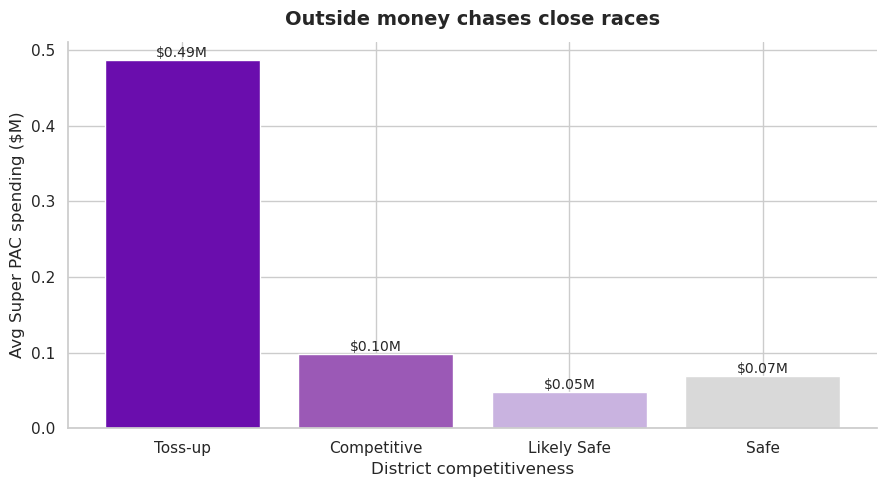

In [24]:
comp_order = ["Toss-up", "Competitive", "Likely Safe", "Safe"]
comp_data = (final_df[final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])]
             .groupby("competitiveness")["superpac_total"].mean()
             .reindex(comp_order) / 1_000_000)

fig, ax = plt.subplots()
bars = ax.bar(comp_data.index, comp_data.values,
              color=[COMP_COLORS[c] for c in comp_order])
ax.set_title("Outside money chases close races")
ax.set_xlabel("District competitiveness")
ax.set_ylabel("Avg Super PAC spending ($M)")
for b, v in zip(bars, comp_data.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"${v:.2f}M",
            ha="center", va="bottom", fontsize=10)
sns.despine(); plt.tight_layout(); plt.show()

In [25]:
# Top 10 districts by Super PAC spending
q3 = pd.read_sql_query("""
    -- Query 3: Top 10 districts by total Super PAC spending
    SELECT 
        CAND_OFFICE_ST,
        CAND_OFFICE_DISTRICT,
        competitiveness,
        winner_party,
        ROUND(SUM(superpac_total), 2) AS total_superpac
    FROM main
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY CAND_OFFICE_ST, CAND_OFFICE_DISTRICT
    ORDER BY total_superpac DESC
    LIMIT 10
""", conn)
display(q3)

,CAND_OFFICE_ST,CAND_OFFICE_DISTRICT,competitiveness,winner_party,total_superpac
0,NY,16.0,Safe,DEMOCRAT,16838475.0
1,AK,0.0,Toss-up,REPUBLICAN,15764631.0
2,CA,47.0,Toss-up,DEMOCRAT,14142592.0
3,NY,19.0,Toss-up,DEMOCRAT,11607172.0
4,MO,1.0,Safe,DEMOCRAT,11602210.0
5,CA,45.0,Toss-up,DEMOCRAT,8733395.0
6,CO,8.0,Toss-up,REPUBLICAN,8283007.0
7,SC,1.0,Likely Safe,REPUBLICAN,7382003.0
8,NE,2.0,Toss-up,REPUBLICAN,6994673.0
9,VA,7.0,Toss-up,DEMOCRAT,6920032.0


In [26]:
# Comparing share of competitive districts
# among high-spending vs all districts
q6 = pd.read_sql_query("""
    -- Query 6: Are high-spending districts more likely to be competitive?
    -- Compares the share of competitive districts among those with above-average
    -- Super PAC spending vs all districts
    SELECT 
        group_label,
        COUNT(*) AS num_districts,
        SUM(CASE WHEN competitiveness IN ('Toss-up', 'Competitive') 
            THEN 1 ELSE 0 END) AS num_competitive,
        ROUND(100.0 * SUM(CASE WHEN competitiveness IN ('Toss-up', 'Competitive') 
            THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_competitive
    FROM (
        SELECT 
            CAND_OFFICE_ST,
            CAND_OFFICE_DISTRICT,
            competitiveness,
            SUM(superpac_total) AS total_superpac,
            CASE 
                WHEN SUM(superpac_total) > (
                    SELECT AVG(superpac_total) FROM main
                    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
                ) THEN 'Above average spending'
                ELSE 'Below average spending'
            END AS group_label
        FROM main
        WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
        GROUP BY CAND_OFFICE_ST, CAND_OFFICE_DISTRICT
    )
    GROUP BY group_label
""", conn)
display(q6)

,group_label,num_districts,num_competitive,pct_competitive
0,Above average spending,130,73,56.2
1,Below average spending,306,36,11.8


In [27]:
# what percentage of state's Super PAC spending
# goes to each district (shows concentration of money within states)
q7 = pd.read_sql_query("""
    -- Query 7: Window function - each district's share of total Super PAC 
    -- spending in its state. Shows whether money is concentrated in one district
    -- or spread across the state.
    SELECT 
        CAND_OFFICE_ST,
        CAND_OFFICE_DISTRICT,
        competitiveness,
        ROUND(SUM(superpac_total), 2) AS district_superpac,
        ROUND(SUM(superpac_total) * 100.0 / SUM(SUM(superpac_total)) OVER (
            PARTITION BY CAND_OFFICE_ST
        ), 1) AS pct_of_state_total
    FROM main
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY CAND_OFFICE_ST, CAND_OFFICE_DISTRICT, competitiveness
    ORDER BY CAND_OFFICE_ST, district_superpac DESC
    LIMIT 20
""", conn)
display(q7)

,CAND_OFFICE_ST,CAND_OFFICE_DISTRICT,competitiveness,district_superpac,pct_of_state_total
0,AK,0.0,Toss-up,15764631.0,100.0
1,AL,2.0,Competitive,3124498.0,52.7
2,AL,1.0,Safe,2731059.0,46.0
3,AL,7.0,Likely Safe,75926.0,1.3
4,AL,3.0,Safe,0.0,0.0
5,AL,4.0,Safe,0.0,0.0
6,AL,5.0,Safe,0.0,0.0
7,AL,6.0,Safe,0.0,0.0
8,AR,3.0,Safe,188992.0,54.5
9,AR,2.0,Likely Safe,156346.0,45.1


Super PACs spend where the race is close. Toss-up districts drew an average of about **\$486K** in Super PAC spending per candidate; Safe districts drew **\$69K** — roughly seven times less, and the drop-off is smooth across all four categories. The pattern holds when we flip the question around: among districts with above-average outside spending, **56%** were genuinely competitive, versus just **12%** of low-spending districts, a five-fold difference.

The money is concentrated even *within* states. In most states, one or two districts absorb nearly all of the outside dollars while safe seats receive little or nothing (in Alabama, two districts split 99% of the state's total). New York's 16th led the entire country at **\$16.8M**, driven by a high-profile primary that pulled in national money. The picture is of Super PACs behaving like rational investors: **they put their money where the outcome is genuinely in doubt**.

## 2. Does the money win?

If outside money chases close races, the natural next question is whether it tips them. We begin with the simplest possible comparison, then control for the two factors that obviously confound it — **incumbency and party**.

In [28]:
# Win rate by Super PAC support (competitive districts)
model_df["has_superpac_label"] = model_df["has_superpac"].map({
    0: "No Super PAC Support",
    1: "Has Super PAC Support",
})

winrate = model_df.groupby("has_superpac_label")["won"].agg(
    Candidates="count",
    Wins="sum",
    win_rate="mean",
).round(3)
winrate["Win rate (%)"] = (winrate["win_rate"] * 100).round(1)
winrate["win_rate_pct"] = winrate["Win rate (%)"]   # потрібно для графіка нижче
winrate.index.name = "Group"

display(
    winrate[["Candidates", "Wins", "Win rate (%)"]]
    .style.format({"Win rate (%)": "{:.1f}%"})
)


,Candidates,Wins,Win rate (%)
Group,,,
Has Super PAC Support,229,126,55.0%
No Super PAC Support,595,242,40.7%



The raw gap is real: in competitive districts, candidates with any Super PAC support in their favor won **55%** of the time, versus **40.7%** for those with none — a 14-point spread that matters when margins are often in single digits.

But a raw gap cannot tell us whether the money *won* those races or simply *picked* candidates who were already likely to win. To separate the two, we model outcomes while holding incumbency and party constant.

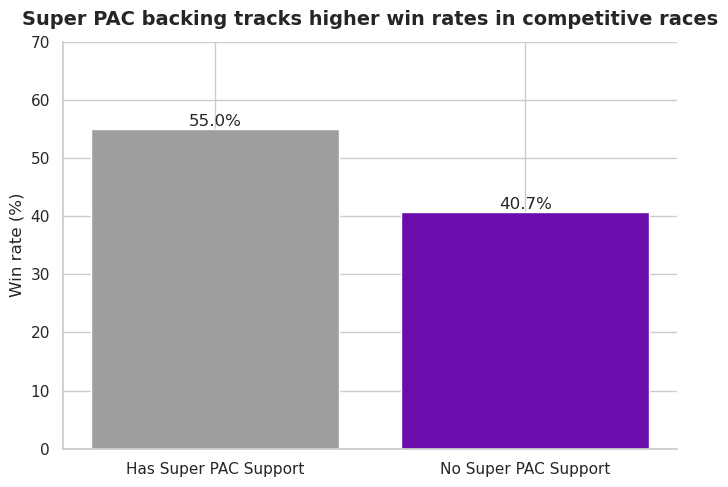

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(winrate.index, winrate["win_rate_pct"], color=[NEUTRAL, ACCENT])
ax.set_title("Super PAC backing tracks higher win rates in competitive races")
ax.set_xlabel(""); ax.set_ylabel("Win rate (%)"); ax.set_ylim(0, 70)
for b, v in zip(bars, winrate["win_rate_pct"]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=12)
sns.despine(); plt.tight_layout(); plt.show()

In [30]:
# Super PAC spending for winners vs losers
# Compares how much Super PAC money went to winning vs losing candidates

q4 = pd.read_sql_query("""
    SELECT
        m.CAND_PTY_AFFILIATION,
        d.competitiveness,
        CASE
            WHEN (m.CAND_PTY_AFFILIATION = 'DEM' AND m.winner_party = 'DEMOCRAT')
              OR (m.CAND_PTY_AFFILIATION = 'REP' AND m.winner_party = 'REPUBLICAN')
            THEN 'Winner'
            ELSE 'Loser'
        END AS outcome,
        COUNT(*) AS num_candidates,
        ROUND(AVG(m.superpac_for), 2) AS avg_superpac_for,
        ROUND(AVG(m.superpac_against), 2) AS avg_superpac_against,
        ROUND(AVG(m.TTL_DISB), 2) AS avg_candidate_spending
    FROM main m
    JOIN districts d
        ON m.CAND_OFFICE_ST = d.CAND_OFFICE_ST
       AND m.CAND_OFFICE_DISTRICT = d.CAND_OFFICE_DISTRICT
    WHERE m.CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY m.CAND_PTY_AFFILIATION, d.competitiveness, outcome
    ORDER BY m.CAND_PTY_AFFILIATION, outcome
""", conn)

display(q4)

,CAND_PTY_AFFILIATION,competitiveness,outcome,num_candidates,avg_superpac_for,avg_superpac_against,avg_candidate_spending
0,DEM,Competitive,Loser,102,32654.72,24844.53,670597.13
1,DEM,Likely Safe,Loser,204,1034.32,21.17,145890.74
2,DEM,Safe,Loser,197,31.35,507.90,139279.88
3,DEM,Toss-up,Loser,76,296250.14,268415.47,2209051.09
4,DEM,Competitive,Winner,162,132996.81,18829.51,1628036.56
5,DEM,Likely Safe,Winner,142,52942.19,6595.63,795021.24
6,DEM,Safe,Winner,340,64864.51,80110.87,1128745.06
7,DEM,Toss-up,Winner,83,358126.53,252686.25,2507692.57
8,REP,Competitive,Loser,235,12855.50,12338.09,309168.49
9,REP,Likely Safe,Loser,146,752.08,0.00,77864.89


Winners consistently drew more outside support than losers, Democratic winners averaged about **\$111K** versus **\$45K** for losing Democrats; Republican winners **\$70K** versus **\$31K**. But notice that the gap in candidates' *own* spending was even larger. That is the first hint that fundraising capacity, not outside money, is doing much of the work.

To pin this down, we fit two models on competitive districts only — **Toss-ups and Competitive** seats, where money is most likely to matter (Safe districts are excluded because their outcomes are driven by partisan lean, not spending). Each model uses six predictors: Super PAC spending for and against the candidate, the candidate's own spending, an indicator for any Super PAC support, party, and incumbency. Spending variables are log-transformed because campaign finance is heavily right-skewed.

In [31]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [32]:
# Define features
X = model_df[[
    "log_superpac_for",
    "log_superpac_against",
    "log_TTL_DISB",
    "has_superpac",
    "party_dem",
    "is_incumbent"
]]

In [33]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_linear = model_df["margin_outcome"]
y_logistic = model_df["won"]

In [34]:
# Train/test split
X_train, X_test, y_train_lin, y_test_lin = train_test_split(
    X_scaled, y_linear, test_size=0.2, random_state=42
)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_scaled, y_logistic, test_size=0.2, random_state=42
)

In [59]:
# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train_lin)
y_pred_lin = lin_model.predict(X_test)

print("=== Model 1: Linear Regression (predicting margin of victory) ===")
print(f"R²: {r2_score(y_test_lin, y_pred_lin):.3f}   |   "
      f"RMSE: {np.sqrt(mean_squared_error(y_test_lin, y_pred_lin)):.3f}")

lin_coefs = (pd.DataFrame({"Predictor": X.columns, "Coefficient": lin_model.coef_})
             .sort_values("Coefficient", ascending=False)
             .reset_index(drop=True))

display(lin_coefs.style.format({"Coefficient": "{:.3f}"}).hide(axis="index"))

=== Model 1: Linear Regression (predicting margin of victory) ===
R²: 0.143   |   RMSE: 8.007


Predictor,Coefficient
is_incumbent,2.858
log_superpac_for,2.087
party_dem,1.395
log_TTL_DISB,0.150
log_superpac_against,-0.053
has_superpac,-2.126


**Model 1 — Linear regression (margin of victory).** The model explains about **14%** of the variation in margin (R² = 0.143; average error roughly 8 points), modest, as expected for something as complex as an election, but enough to rank the predictors. **Incumbency is the strongest** (+2.86 points), followed by party (+1.40 for Democrats in 2024's competitive seats). Super PAC spending *for* a candidate lands between them (+2.09) — a real, positive association. The candidate's own spending adds little once everything else is held constant (+0.15), and spending *against* a candidate has essentially no effect (−0.05).

In [60]:
# Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train_log)
y_pred_log = log_model.predict(X_test)

print("=== Model 2: Logistic Regression (predicting win/loss) ===")
print(f"Accuracy: {accuracy_score(y_test_log, y_pred_log):.3f}")

# classification report as a clean table
report = pd.DataFrame(
    classification_report(y_test_log, y_pred_log, output_dict=True)
).T
display(report.style.format("{:.2f}"))

log_coefs = (pd.DataFrame({"Predictor": X.columns, "Coefficient": log_model.coef_[0]})
             .sort_values("Coefficient", ascending=False)
             .reset_index(drop=True))

display(log_coefs.style.format({"Coefficient": "{:.3f}"}).hide(axis="index"))

=== Model 2: Logistic Regression (predicting win/loss) ===
Accuracy: 0.667


,precision,recall,f1-score,support
0,0.74,0.62,0.67,91.00
1,0.61,0.73,0.66,74.00
accuracy,0.67,0.67,0.67,0.67
macro avg,0.67,0.67,0.67,165.00
weighted avg,0.68,0.67,0.67,165.00


Predictor,Coefficient
is_incumbent,0.828
party_dem,0.548
log_superpac_for,0.534
log_superpac_against,0.075
log_TTL_DISB,-0.052
has_superpac,-0.599


**Model 2 — Logistic regression (win/loss).** The model picks the winner in **67%** of races, well above a 50% coin flip, with precision and recall balanced across both classes (so it is not simply guessing the larger group). The ordering mirrors Model 1: **incumbency first** (0.83), then party (0.55), then Super PAC support (0.53), with own spending near zero (−0.05) and, notably, spending *against* a candidate carrying a small *positive* coefficient (+0.075). Being attacked by outside money does not predict losing; if anything, it signals a candidate worth attacking.

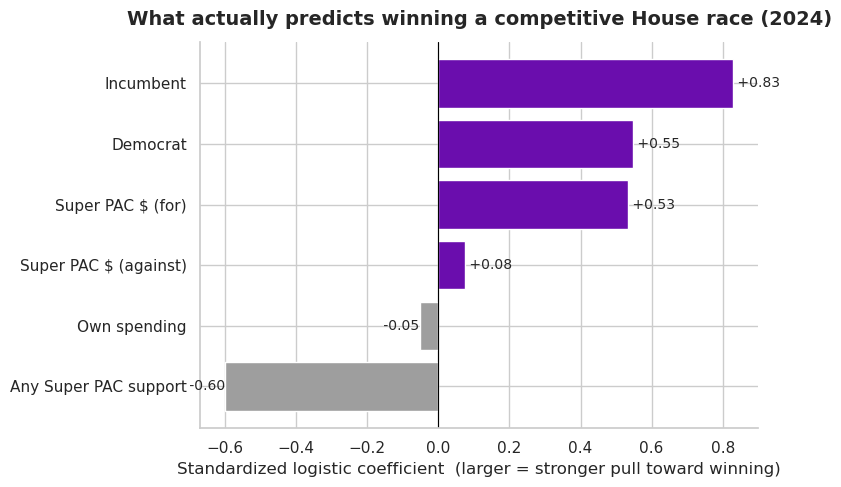

In [37]:
# What predicts winning? Standardized logistic-regression coefficients
import pandas as pd

coef_df = pd.DataFrame({"feature": X.columns, "coef": log_model.coef_[0]})
labels = {
    "is_incumbent": "Incumbent",
    "party_dem": "Democrat",
    "log_superpac_for": "Super PAC $ (for)",
    "log_TTL_DISB": "Own spending",
    "has_superpac": "Any Super PAC support",
    "log_superpac_against": "Super PAC $ (against)",
}
coef_df["label"] = coef_df["feature"].map(labels)
coef_df = coef_df.sort_values("coef")
colors = [ACCENT if c >= 0 else NEUTRAL for c in coef_df["coef"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df["label"], coef_df["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("What actually predicts winning a competitive House race (2024)")
ax.set_xlabel("Standardized logistic coefficient  (larger = stronger pull toward winning)")
for y, v in enumerate(coef_df["coef"]):
    ax.text(v, y, f" {v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=10)
sns.despine(); plt.tight_layout(); plt.show()


Both models tell one story, and the chart makes it visual: **structure beats money.** Who you are (an incumbent) and which party you run under in a given cycle explain more about winning than how much outside money shows up. Super PAC support has a real, positive, but secondary pull.

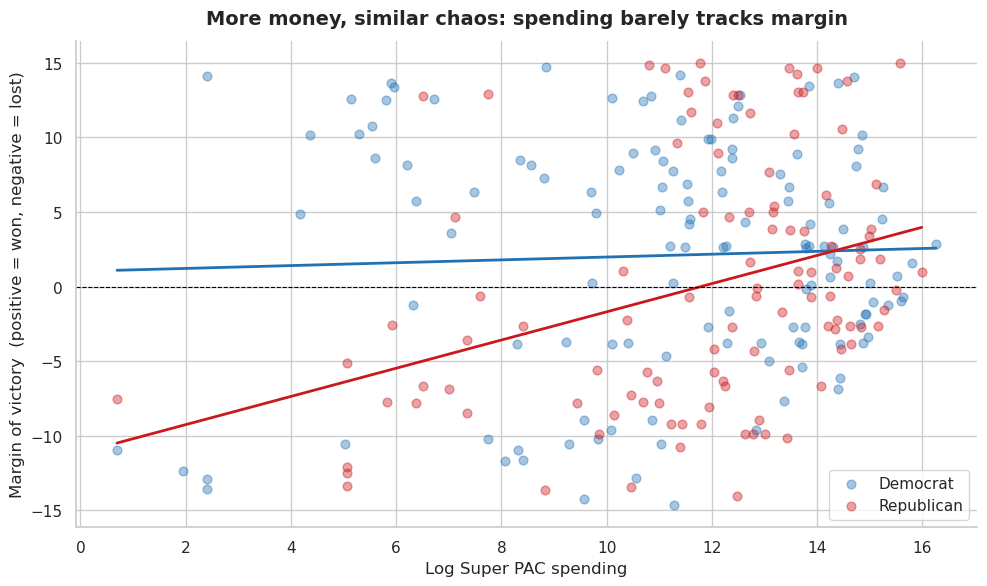

In [38]:
# Super PAC spending vs margin of victory, by party (competitive districts)
scatter_df = model_df[model_df["superpac_total"] > 0].copy()
scatter_df["log_superpac_total"] = np.log1p(scatter_df["superpac_total"])

fig, ax = plt.subplots(figsize=(10, 6))
for party, color, label in [("DEM", DEM, "Democrat"), ("REP", REP, "Republican")]:
    d = scatter_df[scatter_df["CAND_PTY_AFFILIATION"] == party]
    ax.scatter(d["log_superpac_total"], d["margin_outcome"],
               color=color, alpha=0.4, label=label, s=40)
    z = np.polyfit(d["log_superpac_total"], d["margin_outcome"], 1)
    xs = np.linspace(d["log_superpac_total"].min(), d["log_superpac_total"].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), color=color, linewidth=2)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("More money, similar chaos: spending barely tracks margin")
ax.set_xlabel("Log Super PAC spending")
ax.set_ylabel("Margin of victory  (positive = won, negative = lost)")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

The scatter drives the point home. At every level of Super PAC spending, candidates land on both sides of the win/loss line — some win comfortably, others lose badly with similar backing. The wide dispersion is exactly what the low R² predicted: outside money alone is a weak guide to *how much* a candidate wins or loses by. The Republican trend line is steeper but starts lower (many GOP candidates in competitive seats received little support and lost), while the Democratic line is flatter and higher, reflecting Democrats' stronger baseline in 2024's competitive races.

## 3. Does outside money replace a candidate's own fundraising?

A common assumption is that Super PACs let candidates outsource their fundraising, that outside money substitutes for a strong campaign. The data say the opposite.

In [39]:
# does Super PAC support replace or complement candidate spending?
# Compares own spending of candidates with high vs low Super PAC support
q10 = pd.read_sql_query("""
    -- Query 10: Does Super PAC support replace or complement candidate spending?
    -- Negative Super PAC totals are treated as 0 because they likely reflect refunds/adjustments.
    SELECT
        superpac_support_level,
        COUNT(*) AS num_candidates,
        ROUND(AVG(TTL_DISB), 2) AS avg_candidate_spending,
        ROUND(AVG(clean_superpac_total), 2) AS avg_superpac,
        ROUND(AVG(TTL_DISB) / NULLIF(AVG(clean_superpac_total), 0), 2) AS candidate_to_superpac_ratio
    FROM (
        SELECT
            CAND_NAME,
            TTL_DISB,
            CASE 
                WHEN superpac_total < 0 THEN 0
                ELSE superpac_total
            END AS clean_superpac_total,
            CASE
                WHEN 
                    CASE 
                        WHEN superpac_total < 0 THEN 0
                        ELSE superpac_total
                    END > (
                        SELECT AVG(
                            CASE 
                                WHEN superpac_total < 0 THEN 0
                                ELSE superpac_total
                            END
                        )
                        FROM main
                        WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
                        AND superpac_total > 0
                    )
                THEN 'High Super PAC support'
                WHEN superpac_total > 0 THEN 'Low Super PAC support'
                ELSE 'No Super PAC support'
            END AS superpac_support_level
        FROM main
        WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    )
    GROUP BY superpac_support_level
    ORDER BY avg_superpac DESC
""", conn)

display(q10)

,superpac_support_level,num_candidates,avg_candidate_spending,avg_superpac,candidate_to_superpac_ratio
0,High Super PAC support,137,4507559.34,2245989.85,2.01
1,Low Super PAC support,488,2263514.80,63509.17,35.64
2,No Super PAC support,2231,228501.30,0.00,NaN


In [40]:
# JOIN - comparing Super PAC vs candidate own spending by party and competitiveness
q8 = pd.read_sql_query("""
    -- Query 8: Join to compare Super PAC spending vs candidate own spending
    -- broken down by party and district competitiveness
    SELECT 
        m.CAND_PTY_AFFILIATION,
        d.competitiveness,
        COUNT(DISTINCT m.CAND_OFFICE_ST || m.CAND_OFFICE_DISTRICT) AS num_districts,
        ROUND(AVG(m.superpac_total), 2) AS avg_superpac,
        ROUND(AVG(m.TTL_DISB), 2) AS avg_candidate_spending,
        ROUND(AVG(m.superpac_total) / NULLIF(AVG(m.TTL_DISB), 0) * 100, 1) AS superpac_as_pct_of_candidate
    FROM main m
    JOIN districts d 
        ON m.CAND_OFFICE_ST = d.CAND_OFFICE_ST 
        AND m.CAND_OFFICE_DISTRICT = d.CAND_OFFICE_DISTRICT
    WHERE m.CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY m.CAND_PTY_AFFILIATION, d.competitiveness
    ORDER BY m.CAND_PTY_AFFILIATION, avg_superpac DESC
""", conn)
display(q8)

,CAND_PTY_AFFILIATION,competitiveness,num_districts,avg_superpac,avg_candidate_spending,superpac_as_pct_of_candidate
0,DEM,Toss-up,38,588755.02,2364945.70,24.9
1,DEM,Competitive,71,115381.77,1258116.78,9.2
2,DEM,Safe,196,91988.57,765756.90,12.0
3,DEM,Likely Safe,120,25056.91,412296.90,6.1
4,REP,Toss-up,38,393998.51,1134464.49,34.7
5,REP,Competitive,71,84468.33,547561.13,15.4
6,REP,Likely Safe,122,66723.37,525521.64,12.7
7,REP,Safe,191,49434.35,594879.85,8.3


Outside money *complements* a strong campaign; it does not replace one. Candidates with high Super PAC support spent about **\$4.5M** of their own money on average, versus **\$2.3M** for those with low support and just **\$228K** for those with none. The money piles onto strength rather than standing in for it, and in the models above, a candidate's own disbursements out-predicted Super PAC support once structural factors were controlled for. The answer to Question 2 is clean: **outside money is not more important than a candidate's own fundraising.**

## 4. Democrats vs. Republicans

Both parties target the same districts; they differ mainly in how much they rely on outside money.

In [41]:
# Basic summary of Super PAC spending by party
# Shows total and average Super PAC spending for Democrat and Republican candidates
q1 = pd.read_sql_query("""
    -- Query 1: Total and average Super PAC spending by party
    SELECT 
        CAND_PTY_AFFILIATION,
        COUNT(*) AS num_candidates,
        ROUND(SUM(superpac_total), 2) AS total_superpac,
        ROUND(AVG(superpac_total), 2) AS avg_superpac
    FROM candidates
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY CAND_PTY_AFFILIATION
""", conn)
display(q1)

,CAND_PTY_AFFILIATION,num_candidates,total_superpac,avg_superpac
0,DEM,1328,182140390.0,137153.91
1,REP,1569,161250579.0,102772.84


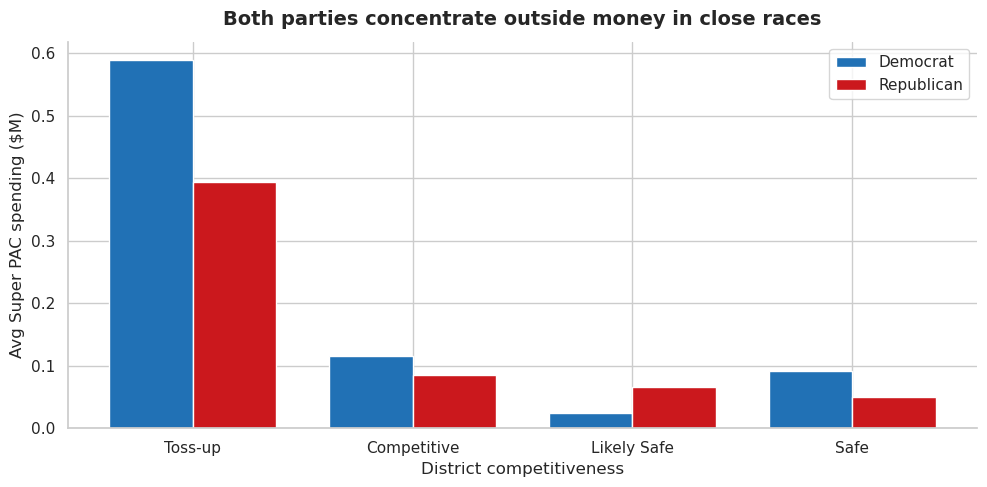

In [42]:
comp_order = ["Toss-up", "Competitive", "Likely Safe", "Safe"]
party_comp = (final_df[final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])]
              .groupby(["CAND_PTY_AFFILIATION", "competitiveness"])["superpac_total"]
              .mean().unstack() / 1_000_000)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_order)); w = 0.38
ax.bar(x - w/2, party_comp.loc["DEM", comp_order], w, label="Democrat", color=DEM)
ax.bar(x + w/2, party_comp.loc["REP", comp_order], w, label="Republican", color=REP)
ax.set_title("Both parties concentrate outside money in close races")
ax.set_xlabel("District competitiveness")
ax.set_ylabel("Avg Super PAC spending ($M)")
ax.set_xticks(x); ax.set_xticklabels(comp_order); ax.legend()
sns.despine(); plt.tight_layout(); plt.show()

Democrats pulled in more Super PAC dollars in absolute terms in competitive districts. But Republicans were *relatively* more dependent on outside money, it made up a larger share of their total campaign resources (about **35%** of own spending in toss-ups, versus **25%** for Democrats). Both parties concentrate outside money in the same place: toss-up and competitive seats. The disagreement is over how much to lean on it, not where to aim it.

## Conclusion

Across every angle, the 2024 House data point the same way: **Super PAC money follows competitiveness and candidate strength rather than creating winners.**

- **Does it win?** On the surface, yes, 55% vs 41% in competitive districts. But once incumbency and party are controlled for, outside money is only a secondary predictor. Super PACs back candidates who are already positioned to win, which makes it hard to credit the money with the victory.
- **More important than own fundraising?** No. A candidate's own spending out-predicted Super PAC support, and outside money tended to pile onto already well-funded campaigns.
- **Where does it go?** Where races are close. Toss-up districts drew roughly five times the outside money of safe ones, and within most states one or two districts absorbed nearly all of it.
- **Partisan differences?** More style than scale. Democrats raised more outside money outright; Republicans leaned on it more heavily as a share of resources. Both concentrated it in competitive seats.

Taken together, this is the **endogeneity problem** that runs through campaign-finance research: money flows to viable candidates, so its independent effect is genuinely difficult to isolate, and honest analysis should say so rather than overclaim.

**Next steps.** Add Cook Political Report PVI scores to control directly for district partisan lean, the key omitted variable here. Extend the analysis to the 2022 cycle to test whether the patterns hold across electoral environments. And examine primaries, where Super PAC spending may move less predictable outcomes than it does in general elections.

## Appendix

Supporting checks and additional queries behind the analysis above: data-quality validation, the spending distribution, and full summary tables.

### Data quality

The modeling dataset has no major missing-value problems — only `CAND_ICI` (incumbency) carried a handful of missing values, and every variable used in the models is complete. There are no problematic duplicate rows; numeric finance variables are stored as numbers, and the binary `won` and `is_incumbent` indicators are correctly encoded.

In [43]:
model_df.isnull().sum()

CAND_ID                 0
CAND_NAME               0
CAND_PTY_AFFILIATION    0
CAND_OFFICE_ST          0
CAND_OFFICE_DISTRICT    0
TTL_DISB                0
superpac_for            0
superpac_against        0
superpac_total          0
dem_pct                 0
rep_pct                 0
margin                  0
competitiveness         0
winner_party            0
CAND_ICI                5
is_incumbent            0
margin_outcome          0
won                     0
has_superpac            0
log_superpac_for        0
log_superpac_against    0
log_TTL_DISB            0
party_dem               0
has_superpac_label      0
dtype: int64

In [44]:
model_df.duplicated().sum()

np.int64(0)

In [45]:
model_df[[
    "log_superpac_for",
    "log_superpac_against",
    "log_TTL_DISB",
    "won",
    "is_incumbent"
]].dtypes

log_superpac_for        float64
log_superpac_against    float64
log_TTL_DISB            float64
won                       int64
is_incumbent              int64
dtype: object

### Spending distribution and outliers

Super PAC spending is heavily right-skewed, which is why we log-transform it before modeling. The extreme values are real, a handful of districts genuinely attract enormous sums, so they are kept rather than trimmed; they represent meaningful variation, not data errors.

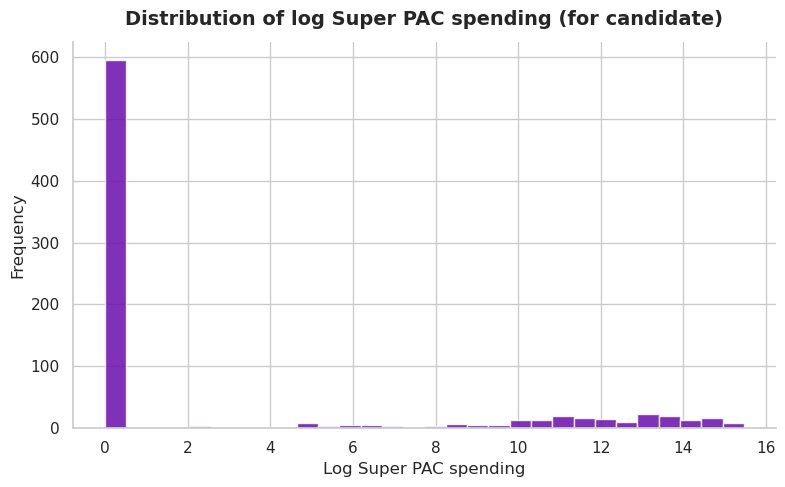

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(model_df["log_superpac_for"], bins=30, color=ACCENT, alpha=0.85)
plt.title("Distribution of log Super PAC spending (for candidate)")
plt.xlabel("Log Super PAC spending"); plt.ylabel("Frequency")
sns.despine(); plt.tight_layout(); plt.show()

### Summary tables

In [47]:
# Summary statistics of Super PAC spending by competitiveness
table1 = final_df[final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])].groupby(
    "competitiveness"
)["superpac_total"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
).round(2).reset_index()

display (table1)

,competitiveness,count,mean,median,min,max
0,Competitive,607,97913.38,0.0,-14629.0,5765534.0
1,Likely Safe,784,48334.86,0.0,-1357.0,4537946.0
2,Safe,1131,69639.14,0.0,-21841.0,12110317.0
3,Toss-up,334,486711.94,0.0,0.0,11510742.0


In [48]:
# Super PAC vs candidate spending by party
table2 = final_df[final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])].groupby(
    "CAND_PTY_AFFILIATION"
).agg(
    num_candidates=("CAND_ID", "count"),
    avg_superpac=("superpac_total", "mean"),
    median_superpac=("superpac_total", "median"),
    avg_candidate_spending=("TTL_DISB", "mean"),
    median_candidate_spending=("TTL_DISB", "median")
).round(2).reset_index()

display(table2)

,CAND_PTY_AFFILIATION,num_candidates,avg_superpac,median_superpac,avg_candidate_spending,median_candidate_spending
0,DEM,1306,139464.31,0.0,966336.43,41536.46
1,REP,1550,100974.98,0.0,625730.23,28622.72
